In [2]:
# Tratamiento de datos
# -----------------------------------------------------------------------
import pandas as pd
import numpy as np

# Visualización
# ------------------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluar linealidad de las relaciones entre las variables
# ------------------------------------------------------------------------------
from scipy.stats import shapiro, kstest

# Imputación de nulos usando métodos avanzados estadísticos
# -----------------------------------------------------------------------
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer

# Configuración
# -----------------------------------------------------------------------
pd.set_option('display.max_columns', None) # para poder visualizar todas las columnas de los DataFrames

# Gestión de los warnings
# -----------------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

In [66]:
#lectura csv final
df_final = pd.read_csv('files/hr_final.csv', index_col = 0)
df_final.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
EmployeeNumber,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,41,True,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,3,2,Sales Executive,4,Single,5993.0,19479,8,True,11,3,1,0,8,0,1,6,4,0,5
2,49,False,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,2,2,Research Scientist,2,Married,5130.0,24907,1,False,23,4,4,1,10,3,3,10,7,1,7
4,37,True,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,92,2,1,Laboratory Technician,3,Single,2090.0,2396,6,True,15,3,2,0,7,3,3,0,0,0,0
5,33,False,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,56,3,1,Research Scientist,3,Married,2909.0,23159,1,True,11,3,3,0,8,3,3,8,7,3,0
7,27,False,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,40,3,1,Laboratory Technician,2,Married,3468.0,16632,9,False,12,3,4,1,6,3,3,2,2,2,2


In [4]:
variables_categoricas = ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',  'MaritalStatus', 'OverTime']

In [5]:
variables_encuesta = ['EnvironmentSatisfaction', 'JobInvolvement','JobSatisfaction','RelationshipSatisfaction','WorkLifeBalance']

In [6]:
variables_salario = ['DailyRate','HourlyRate', 'MonthlyRate','MonthlyIncome','PercentSalaryHike']
variables_tiempo = [ 'TotalWorkingYears','YearsAtCompany','YearsInCurrentRole','YearsSinceLastPromotion','YearsWithCurrManager']
variables_numericas1 = ['DistanceFromHome','JobLevel','PerformanceRating','StockOptionLevel','TrainingTimesLastYear']
variables_numericas2= ['Age', 'Education','NumCompaniesWorked']

In [67]:
# conversión de Attrition en numérica para los gráficos
df_final['AttritionNum'] = df_final['Attrition'].astype(int)

- Correlación de attrition (abandono de la empresa) con las variables categóricas

In [ ]:
def crear_graficos_barras(df, variables):
    
    for col in variables:

        # --- Barplot: tasa de attrition por categoría ---
        plt.figure(figsize=(8, 5))
        tasa = df.groupby(col)['AttritionNum'].mean().sort_values(ascending=False)
        sns.barplot(x=tasa.index, y=tasa.values, palette='mako')
        plt.title(f'Tasa de Abandono por {col}')
        plt.ylabel('Proporción que se va')
        plt.xlabel(col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

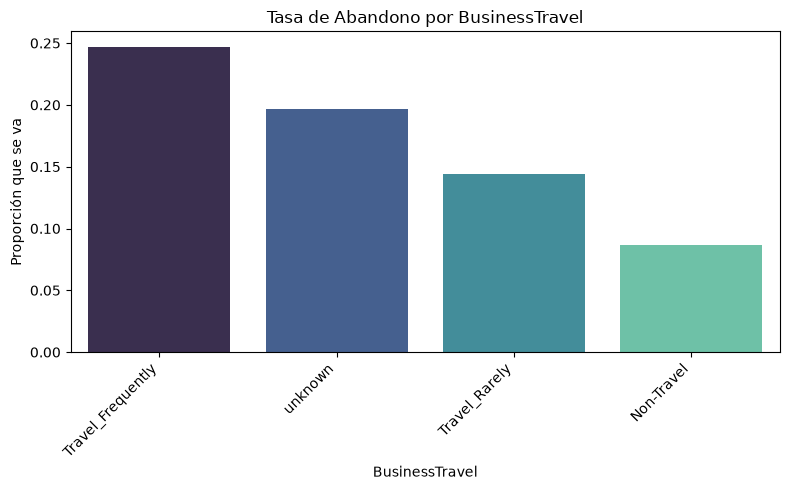

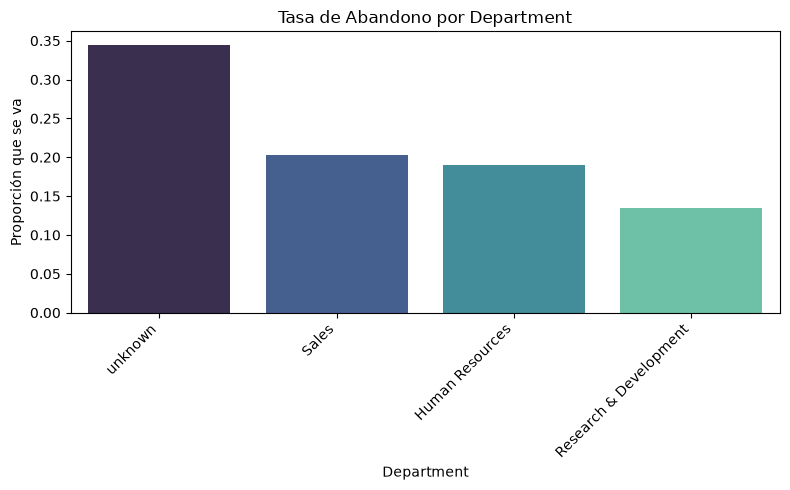

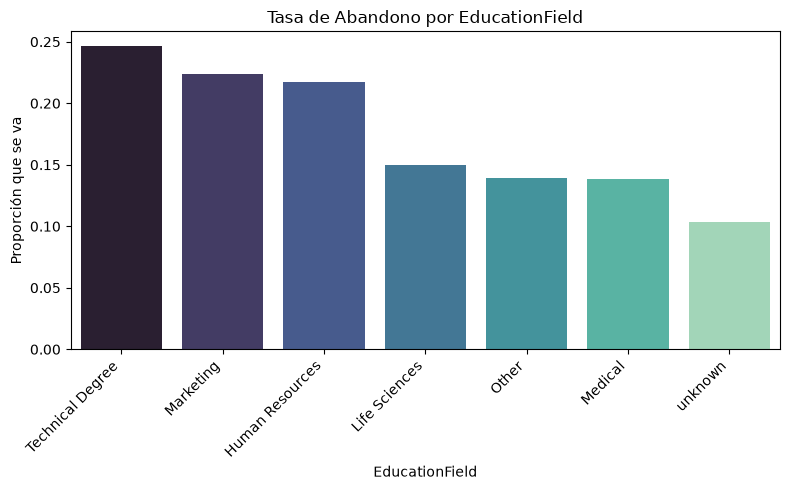

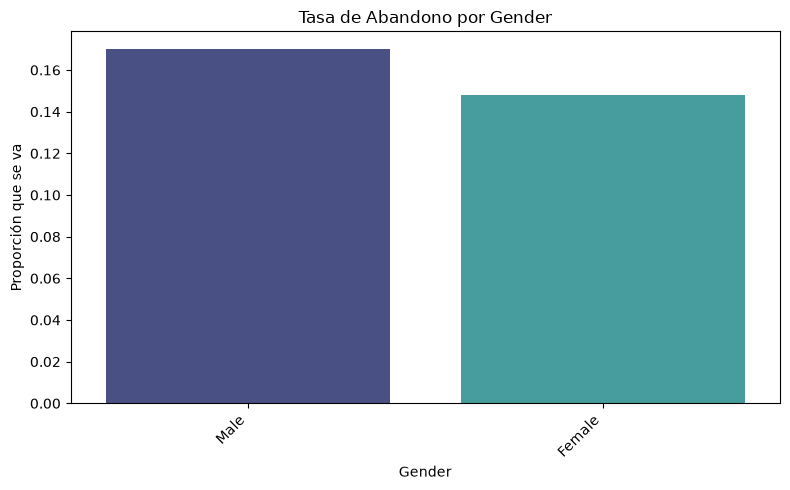

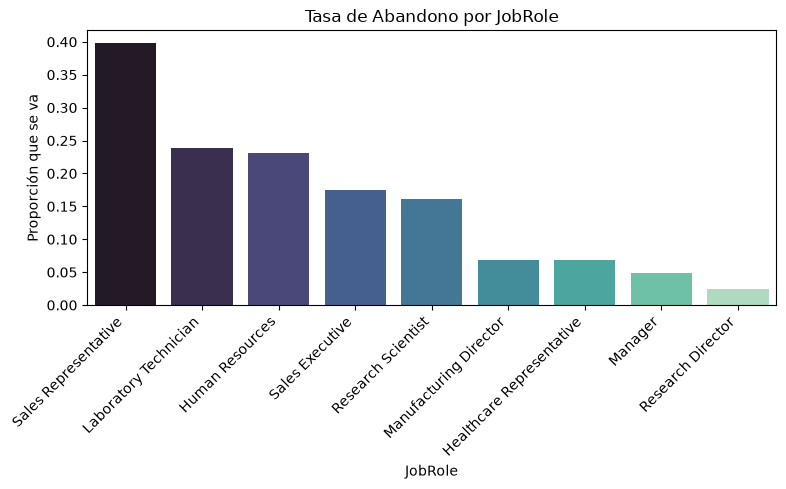

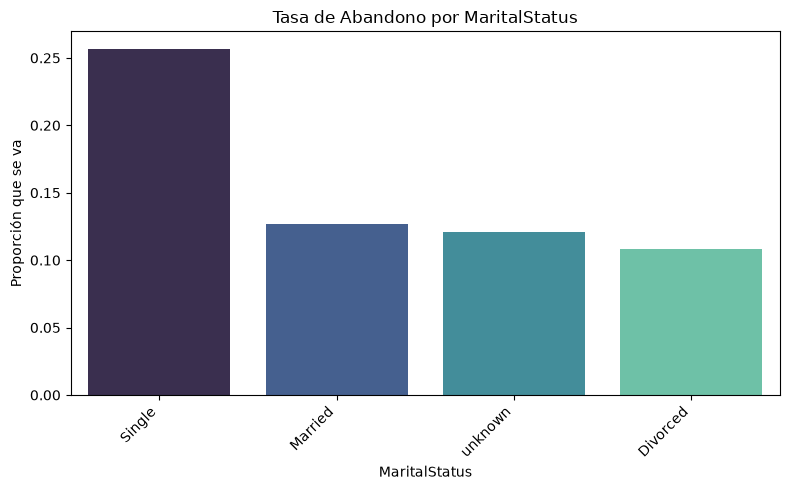

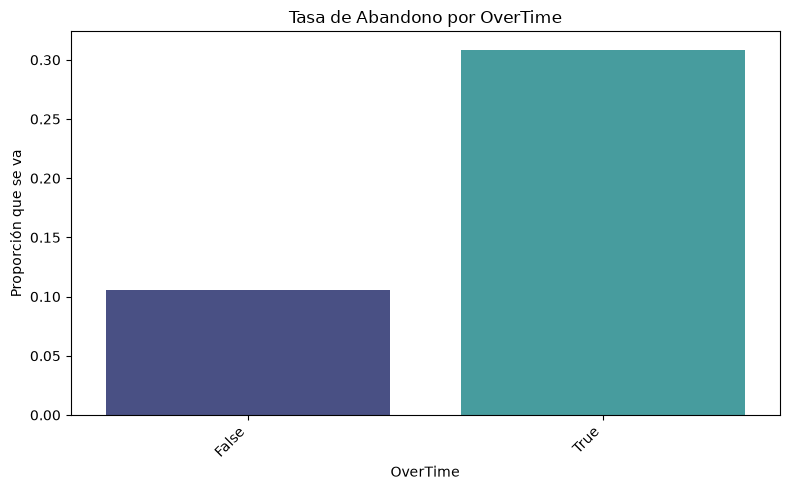

In [9]:
crear_graficos_barras(df_final, variables_categoricas)


- Correlación de attrition con las variables encuesta

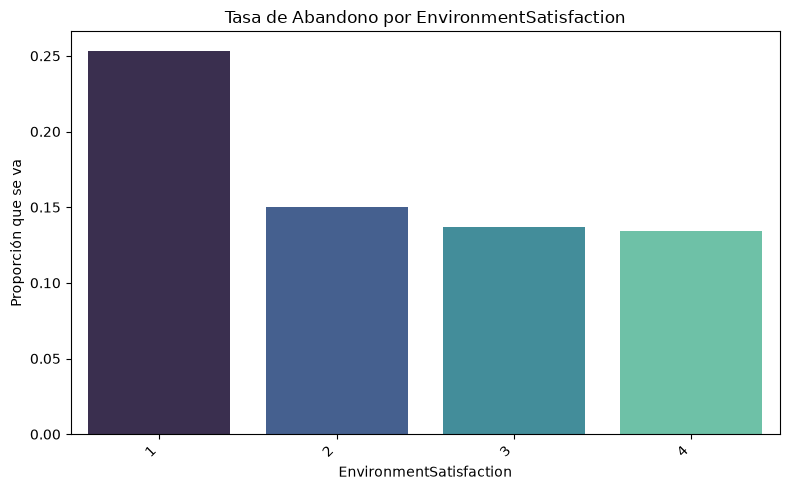

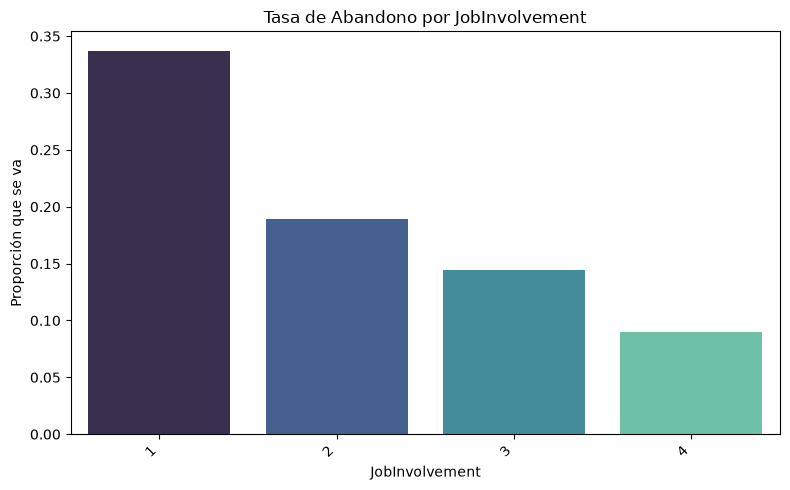

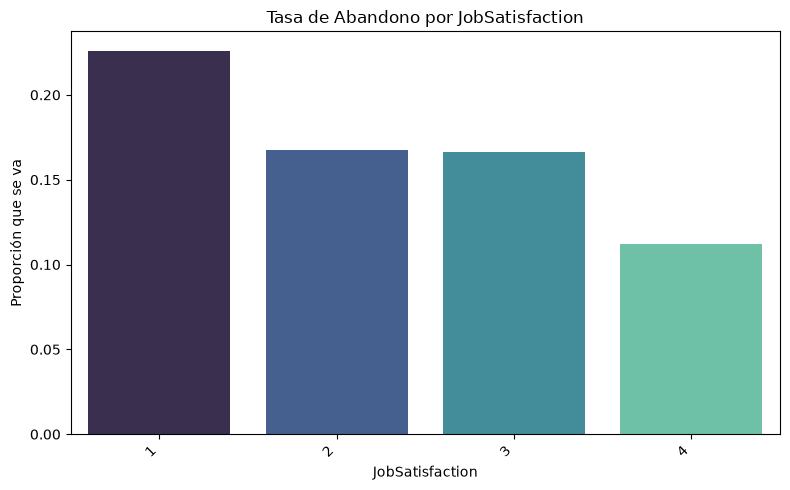

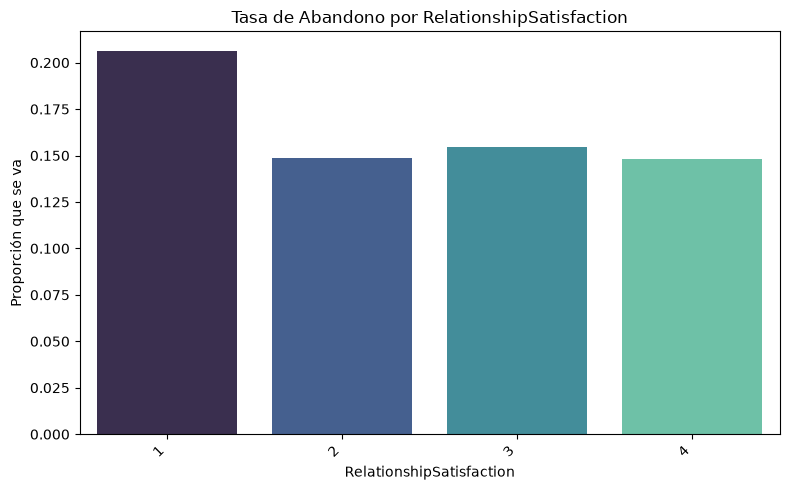

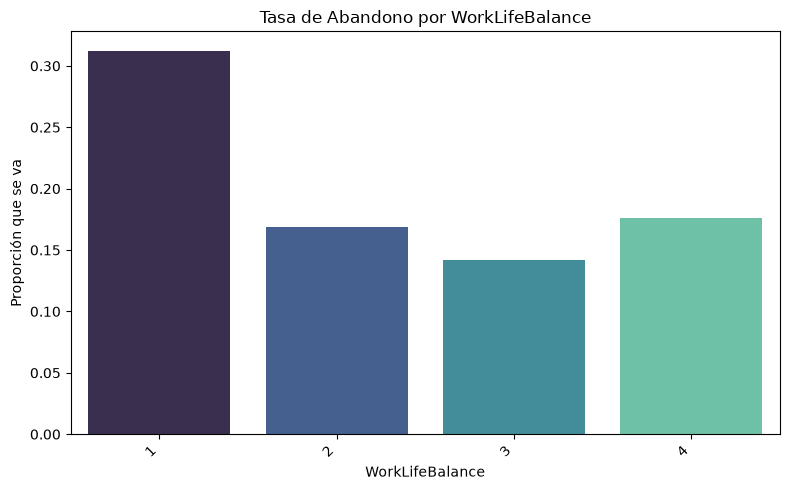

In [10]:
crear_graficos_barras(df_final, variables_encuesta)

- Matriz de correlación con las variables numericas más interesantes

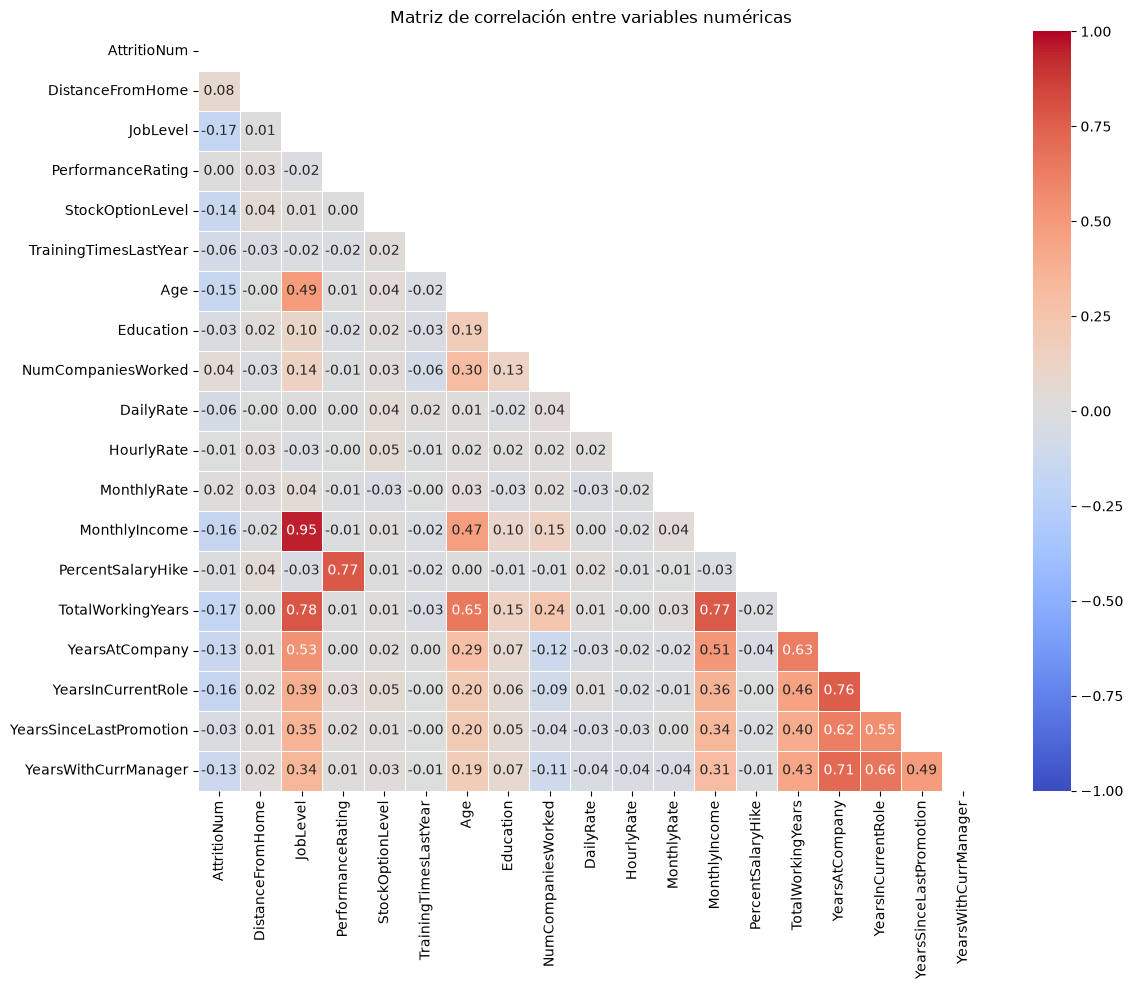

In [ ]:
cols_heatmap = ['AttritionNum'] + list(dict.fromkeys(variables_numericas1 + variables_numericas2 + variables_salario + variables_tiempo)) 
correlacion_matrix = df_final[cols_heatmap].corr()
masc = np.triu(np.ones_like(correlacion_matrix, dtype=bool)) 
plt.figure(figsize=(12, 10))
sns.heatmap(correlacion_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5, mask=masc, vmin=-1, vmax=1)
plt.title('Matriz de correlación entre variables numéricas')
plt.tight_layout()
plt.show()

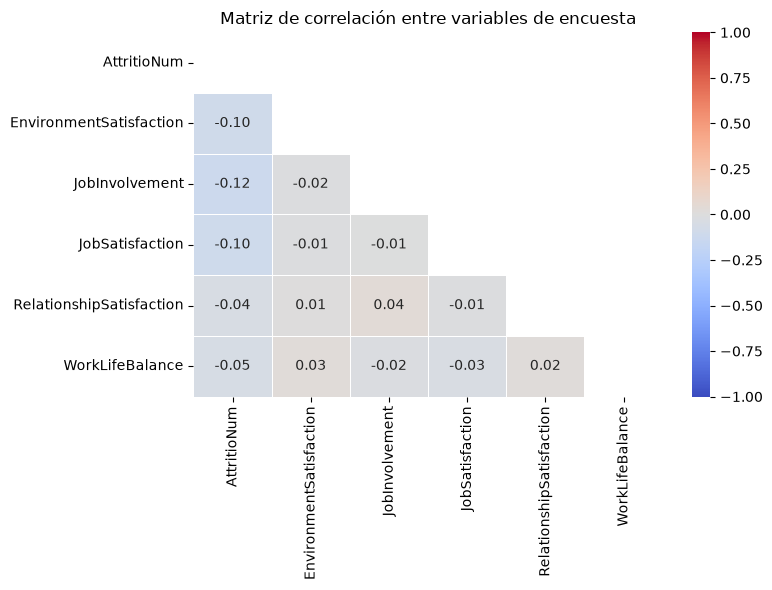

In [ ]:
cols_heatmap = ['AttritionNum'] + variables_encuesta
correlacion_matrix2 = df_final[cols_heatmap].corr(method='spearman')
masc = np.triu(np.ones_like(correlacion_matrix2, dtype=bool)) 
plt.figure(figsize=(8, 6))
sns.heatmap(correlacion_matrix2, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5, mask=masc, vmin=-1, vmax=1)
plt.title('Matriz de correlación entre variables de encuesta')
plt.tight_layout()
plt.show()

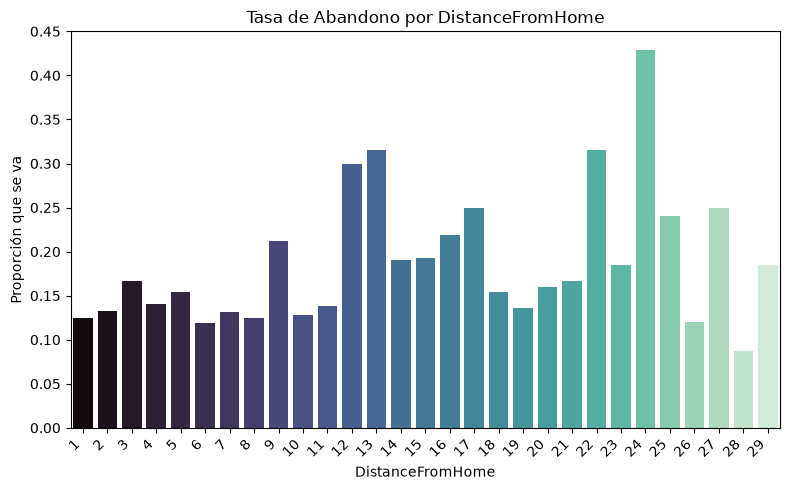

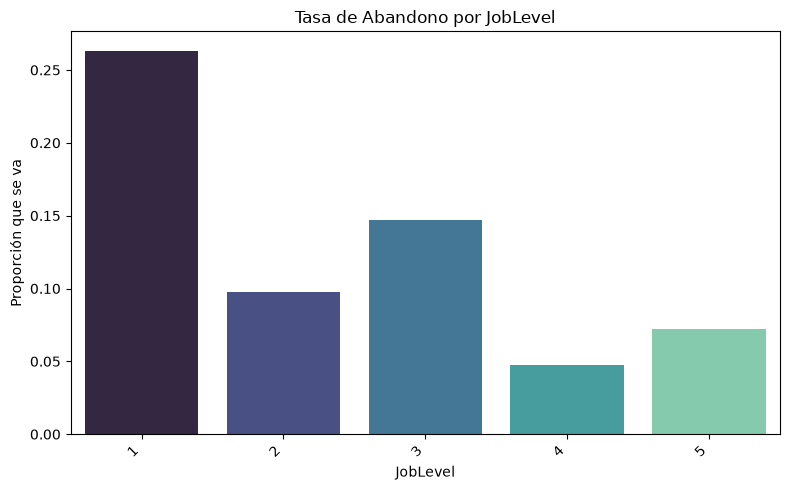

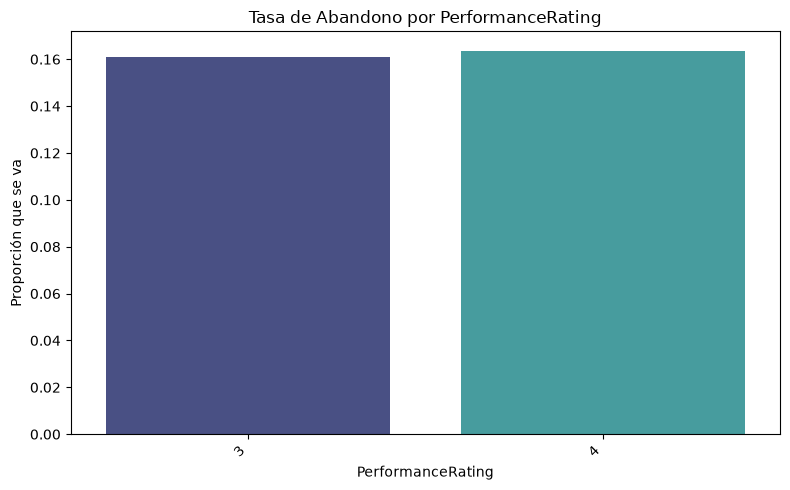

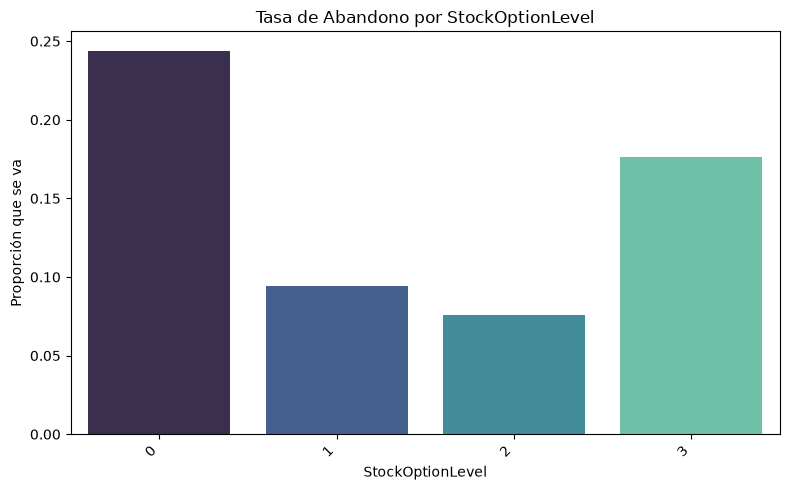

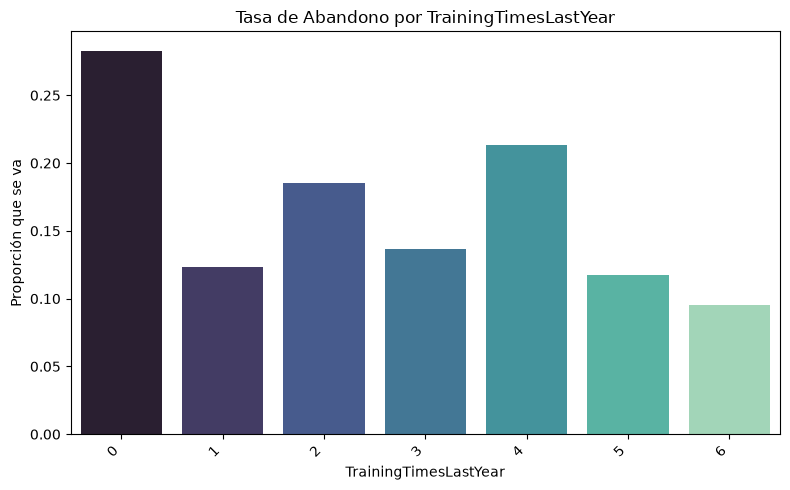

In [13]:
crear_graficos_barras(df_final, variables_numericas1)

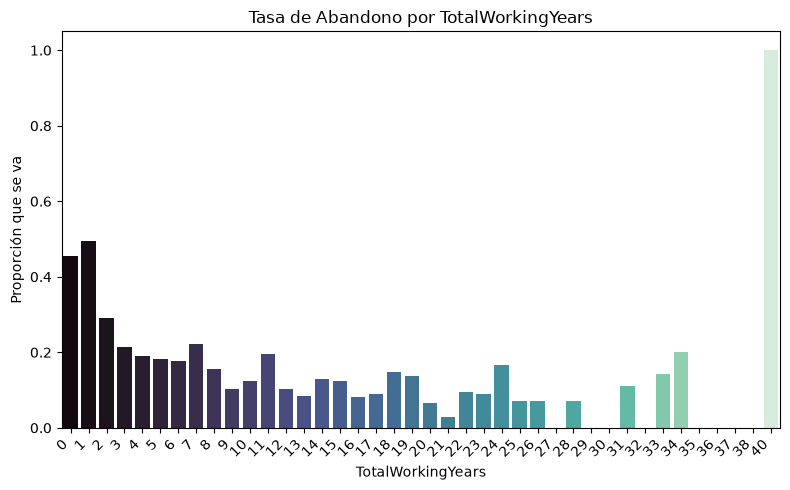

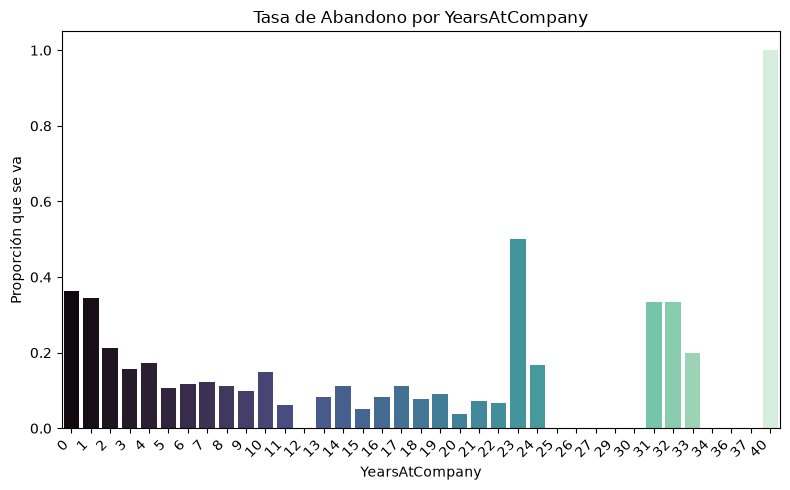

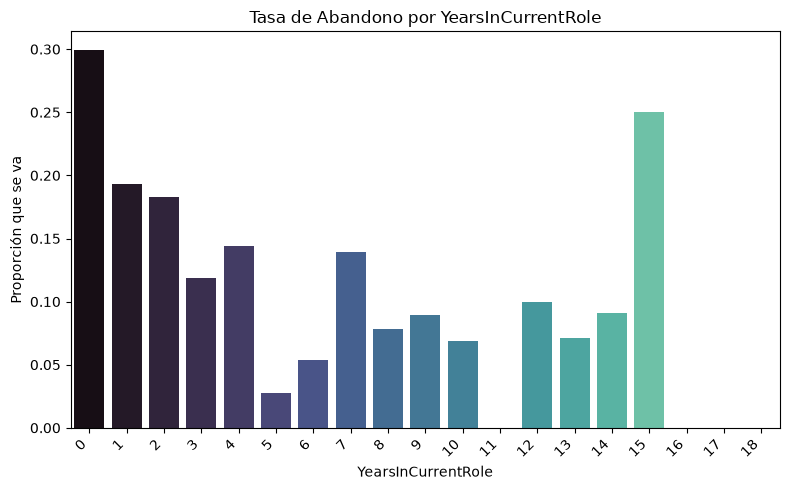

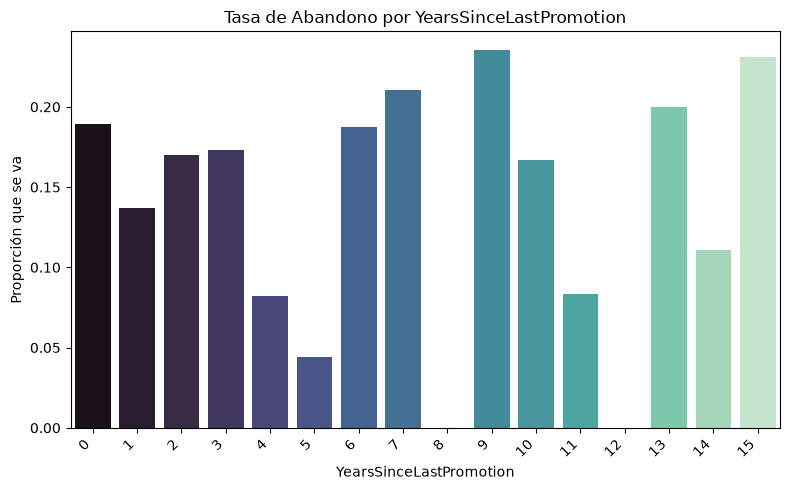

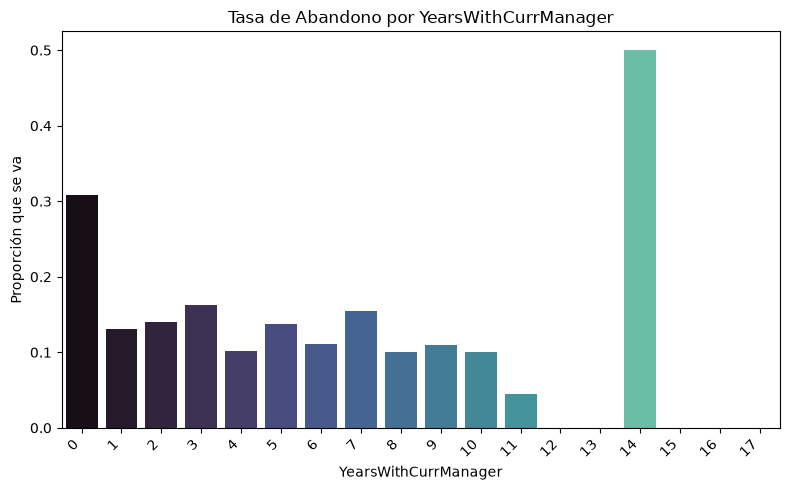

In [14]:
crear_graficos_barras(df_final, variables_tiempo)

In [69]:
#Para comprobar si el alto porcentaje de los que llevan más años trabajando en la compañía y en total y se va es debido a la jubilación


# Personas que llevan más de 35 años en la compañía
mas_35_compania = df_final[df_final["YearsAtCompany"] > 35]

mas_35_compania[["Age", "YearsAtCompany", "TotalWorkingYears", "AttritionNum"]]

,Age,YearsAtCompany,TotalWorkingYears,AttritionNum
EmployeeNumber,,,,
131,58,37,38,0
165,58,40,40,1
374,55,36,37,0
1578,55,36,36,0


In [68]:
# Personas que llevan más de 35 años trabajando en total
mas_35_total = df_final[df_final["TotalWorkingYears"] > 35]

mas_35_total[["Age", "YearsAtCompany", "TotalWorkingYears", "AttritionNum"]]

,Age,YearsAtCompany,TotalWorkingYears,AttritionNum
EmployeeNumber,,,,
112,56,6,37,0
131,58,37,38,0
165,58,40,40,1
254,55,24,36,0
374,55,36,37,0
532,56,7,36,0
597,55,10,37,0
825,58,31,40,1
1250,54,10,36,0


Desconocemos la edad de jubilación del país al que pertenece la empresa. Pero tras ver los gráficos correspondientes a "TotalWorkingYears" y "YearsAtCompany", se podía pensar que el pico de salidas de aquellos que más años llevan trabajando y que más años llevan en la compañía se debe a la jubilación. 

Tras analizar los resultados de la tabla, el pico en el gráfico se debe a que las dos personas de 58 años de edad, que tras haber trabajado 40 años (una de ellas ha hecho toda su vida laboral en la compañía) se han marchado (es decir, el 100% de los que han trabajado 40 años). Lo mismo ocurre con 'YearsAtCompany', la única persona que lleva 40 años en la empresa se ha ido, por tanto corresponde al 100%.

CONCLUSIÓN: No se puede afirmar con rotundidad que se debe a la jubilación ya que desconocemos la edad reglamentaria de retiro en el país en el que opera la empresa, pero apunta a que esas dos personas se han jubilado o prejubilado tras 40 años trabajados, por lo que su caso no sería reseñable para este estudio. 

In [15]:
#Análisis MonthlyIncome

print (f'Mínimo: {df_final["MonthlyIncome"].min()}')
print (f'Máximo: {df_final["MonthlyIncome"].max()}')

Mínimo: 1009.0
Máximo: 19999.0


In [ ]:
#División en 8 intervalos del mismo tamaño
df_final["RangoSalarial"] = pd.cut(
    df_final["MonthlyIncome"],
    bins=8)

In [26]:

df_final["RangoSalarial"].value_counts().sort_index()

RangoSalarial
(990.01, 3382.75]      444
(3382.75, 5756.5]      448
(5756.5, 8130.25]      207
(8130.25, 10504.0]     125
(10504.0, 12877.75]     60
(12877.75, 15251.5]     55
(15251.5, 17625.25]     54
(17625.25, 19999.0]     77
Name: count, dtype: int64

In [22]:
retencion_salario = df_final.groupby("RangoSalarial")["Attrition"].apply(
    lambda x: 1 - x.mean()
) * 100

retencion_salario = retencion_salario.round(2)
retencion_salario.sort_index

<bound method Series.sort_index of RangoSalarial
(990.01, 2908.0]       70.80
(2908.0, 4807.0]       85.84
(4807.0, 6706.0]       88.67
(6706.0, 8605.0]       87.16
(8605.0, 10504.0]      82.08
(10504.0, 12403.0]     91.07
(12403.0, 14302.0]     90.38
(14302.0, 16201.0]    100.00
(16201.0, 18100.0]    100.00
(18100.0, 19999.0]     92.42
Name: Attrition, dtype: float64>

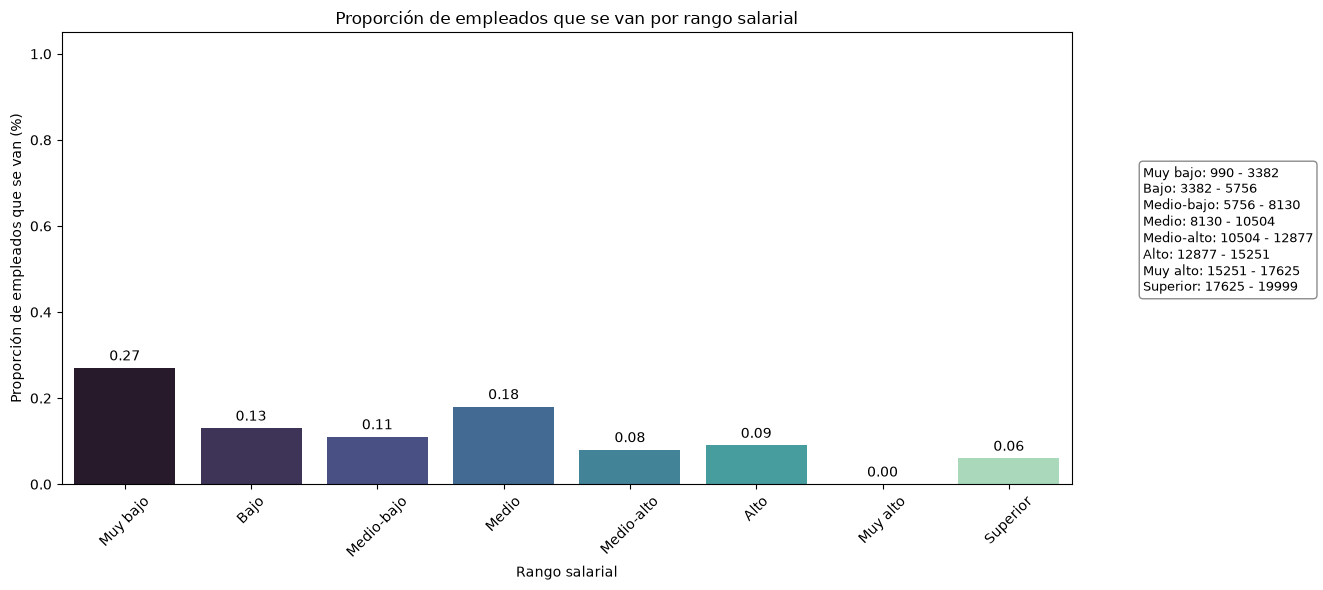

In [ ]:
#Etiquetas para los intervalos
labels_salario = [
    "Muy bajo",
    "Bajo",
    "Medio-bajo",
    "Medio",
    "Medio-alto",
    "Alto",
    "Muy alto",
    "Superior"
]
#Creamos la columna Rango salarial
df_final["RangoSalarial"] = pd.cut(
    df_final["MonthlyIncome"],
    bins=8,
    labels=labels_salario
)

proporcion_salida_salario = (
    df_final
    .groupby("RangoSalarial", observed=True)["AttritionNum"]
    .mean()
    .round(2)
)

intervalos_salario = pd.cut(
    df_final["MonthlyIncome"],
    bins=8
).cat.categories

#Gráfico
texto_leyenda = "\n".join(
    [
        f"{categoria}: {int(intervalo.left)} - {int(intervalo.right)}"
        for categoria, intervalo in zip(labels_salario, intervalos_salario)
    ]
)

plt.figure(figsize=(14, 6))

ax = sns.barplot(
    x=proporcion_salida_salario.index,
    y=proporcion_salida_salario.values,
    order=labels_salario,
    palette='mako'
)

plt.title("Proporción de empleados que se van por rango salarial")
plt.xlabel("Rango salarial")
plt.ylabel("Proporción de empleados que se van (%)")
plt.xticks(rotation=45)
plt.ylim(0, 1.05)

for i, valor in enumerate(proporcion_salida_salario.values):
    ax.text(
        i,
        valor + 0.01,
        f"{valor:.2f}",
        ha="center",
        va="bottom"
    )

plt.gcf().text(
    0.82,
    0.5,
    texto_leyenda,
    fontsize=9,
    ha="left",
    va="bottom",
    bbox=dict(
        boxstyle="round",
        facecolor="white",
        edgecolor="gray",
        alpha=0.9
    )
)

plt.tight_layout(rect=[0, 0, 0.78, 1])
plt.show()